<a href="https://colab.research.google.com/github/springboardmentor442n-coder/Network-Anomaly-Detection-and-Predictive-Intrusion-Monitoring-Platform/blob/pujitha/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn xgboost joblib pyarrow

In [3]:
!wget -q -O unsw-nb15.zip "https://www.kaggle.com/api/v1/datasets/download/strgenix/unsw-nb15"

print("Dataset downloaded successfully! ✅")

Dataset downloaded successfully! ✅


In [5]:
import os

if os.path.exists("unsw-nb15.zip"):
    os.remove("unsw-nb15.zip")

print("Old file removed. ✅")

Old file removed. ✅


In [6]:
import requests

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"

response = requests.get(url)

print("Status:", response.status_code)
print("File size:", len(response.content))

Status: 200
File size: 19109424


In [7]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [9]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'sample_data']


In [10]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully! ✅")

Kaggle API configured successfully! ✅


In [11]:
!kaggle datasets list -s "UNSW-NB15"

ref                                                            title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dhoogla/unswnb15                                               UNSW-NB15                                           12286680  2024-09-09 09:28:06.997000          19173        107                1  
dhoogla/nfunswnb15v2                                           NF-UNSW-NB15-V2                                     49538453  2023-01-13 20:36:09.737000          63307         13                1  
sankurisrinath/nf-unsw-nb15-v2csv                              NF-UNSW-NB15-V2.CSV                                 37060516  2023-06-22 05:28:02.280000           1515         31                1  
mrwellsdavid/un

In [12]:
!mkdir -p /content/unsw_download

!kaggle datasets download -d dhoogla/unswnb15 \
    -p /content/unsw_download

print("Download completed!")

Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
100% 11.7M/11.7M [00:01<00:00, 7.39MB/s]

Download completed!


In [13]:
!ls -lh /content/unsw_download

total 12M
-rw-r--r-- 1 root root 12M Sep  9  2024 unswnb15.zip


In [14]:
!mkdir -p /content/unsw_dataset

!unzip -o /content/unsw_download/*.zip \
    -d /content/unsw_dataset

print("Dataset extracted successfully!")

Archive:  /content/unsw_download/unswnb15.zip
  inflating: /content/unsw_dataset/UNSW_NB15_testing-set.parquet  
  inflating: /content/unsw_dataset/UNSW_NB15_training-set.parquet  
Dataset extracted successfully!


In [15]:
import os

for root, dirs, files in os.walk("/content/unsw_dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/unsw_dataset/UNSW_NB15_testing-set.parquet
/content/unsw_dataset/UNSW_NB15_training-set.parquet


In [16]:
!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn joblib pyarrow

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
train_path = "/content/unsw_dataset/UNSW_NB15_training-set.parquet"
test_path = "/content/unsw_dataset/UNSW_NB15_testing-set.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

Training shape: (175341, 36)
Testing shape : (82332, 36)

Columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [19]:
print("Training columns:")
print(train_df.dtypes)

print("\nTarget distribution:")
print(train_df["label"].value_counts())

Training columns:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd      

In [20]:
TARGET = "label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# attack_cat is not needed for binary classification
if "attack_cat" in X_train.columns:
    X_train = X_train.drop(columns=["attack_cat"])
    X_test = X_test.drop(columns=["attack_cat"])

# ID is not useful for prediction
for col in ["id", "ID"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (175341, 34)
X_test : (82332, 34)


In [21]:
encoders = {}

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for col in categorical_columns:
    encoder = LabelEncoder()

    combined = pd.concat([
        X_train[col].astype(str),
        X_test[col].astype(str)
    ])

    encoder.fit(combined)

    X_train[col] = encoder.transform(
        X_train[col].astype(str)
    )

    X_test[col] = encoder.transform(
        X_test[col].astype(str)
    )

    encoders[col] = encoder

print("\nCategorical encoding completed!")

Categorical columns:
['proto', 'service', 'state']

Categorical encoding completed!


In [22]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in training:", X_train.isnull().sum().sum())
print("Missing values in testing :", X_test.isnull().sum().sum())

Missing values in training: 0
Missing values in testing : 0


In [23]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("Training XGBoost model...")

model.fit(
    X_train,
    y_train
)

print("Training completed! ✅")

Training XGBoost model...
Training completed! ✅


In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"MODEL ACCURACY: {accuracy * 100:.2f}%")
print("=" * 50)

MODEL ACCURACY: 87.01%


In [26]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)


Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332



In [27]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9810


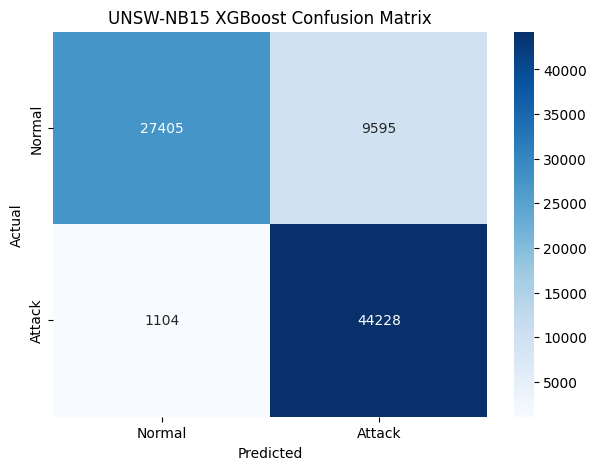

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UNSW-NB15 XGBoost Confusion Matrix")

plt.show()

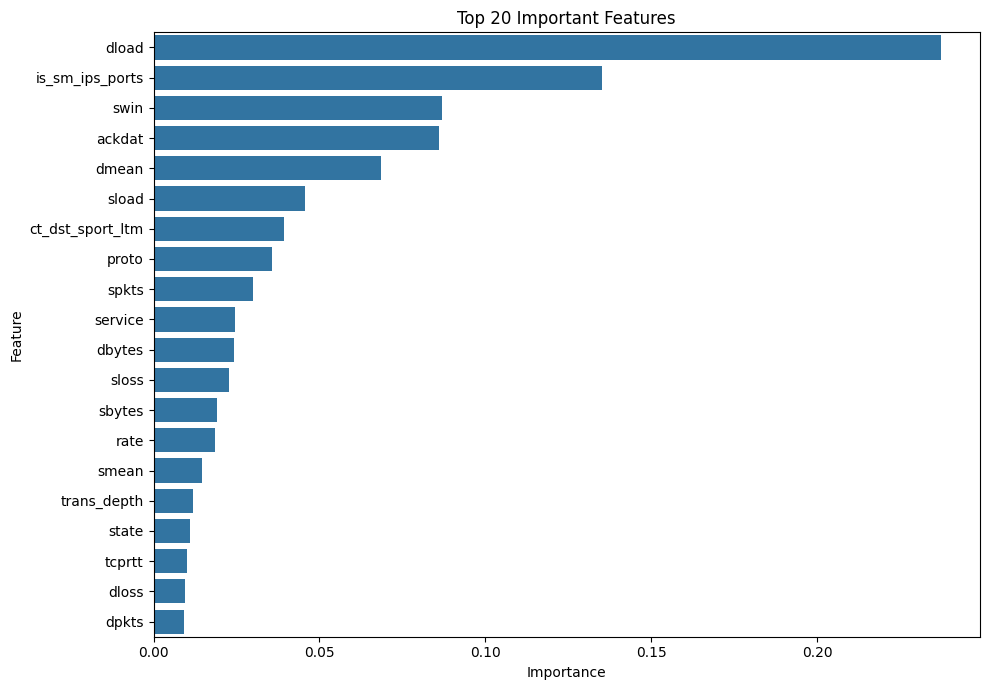

In [29]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [30]:
joblib.dump(
    model,
    "/content/unsw_nb15_xgboost_model.joblib"
)

joblib.dump(
    encoders,
    "/content/unsw_nb15_feature_encoders.joblib"
)

joblib.dump(
    list(X_train.columns),
    "/content/unsw_nb15_features.joblib"
)

print("Model files saved successfully! ✅")

Model files saved successfully! ✅


In [31]:
from google.colab import files

files.download("/content/unsw_nb15_xgboost_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
files.download("/content/unsw_nb15_feature_encoders.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
files.download("/content/unsw_nb15_features.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"F1 Score (%): {f1 * 100:.2f}%")

F1 Score: 0.8921
F1 Score (%): 89.21%


In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.96      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332

